In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('../data/processed/rfm_data.csv')

In [4]:
df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,325,1,77183.60,1,1,5,115,Need Attention
1,1,7,4310.00,5,4,5,545,Champions
2,74,4,1797.24,2,3,4,234,At Risk
3,18,1,1757.55,4,1,4,414,Potential Loyalists
4,309,1,334.40,1,1,2,112,Lost Customers


In [5]:
df.columns

Index(['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score',
       'RFM_Score', 'Segment'],
      dtype='object')

In [6]:
rfm_features = df[['Recency','Frequency','Monetary']]

In [7]:
rfm_features.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272245,2048.688081
std,100.014169,7.697975,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [9]:
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features.columns,
    index=rfm_features.index
)

In [10]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425128,8.363010
1,-0.905340,0.354388,0.251699
2,-0.175360,-0.035370,-0.027988
3,-0.735345,-0.425128,-0.032406
4,2.174578,-0.425128,-0.190812


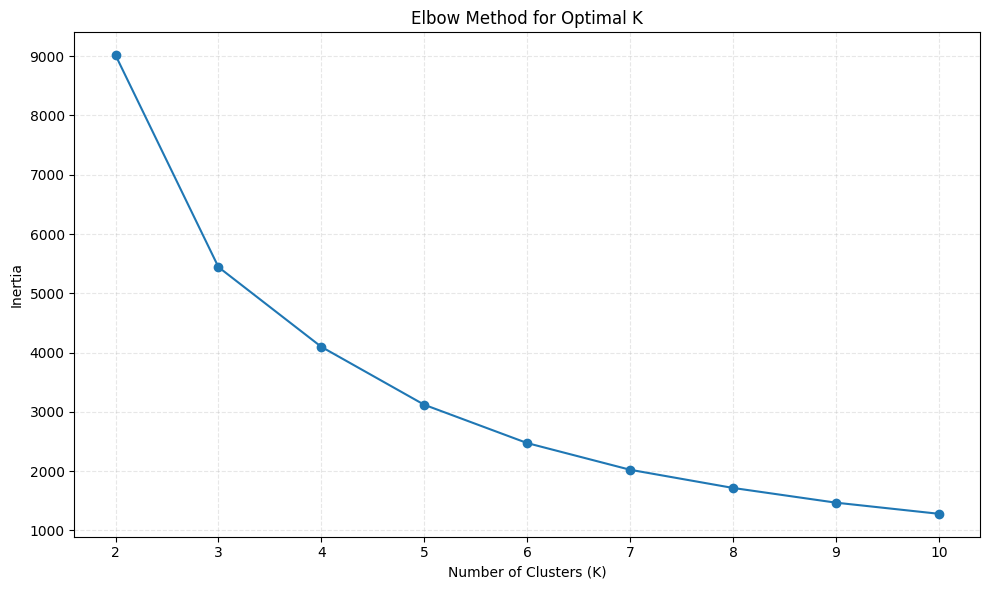

In [11]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

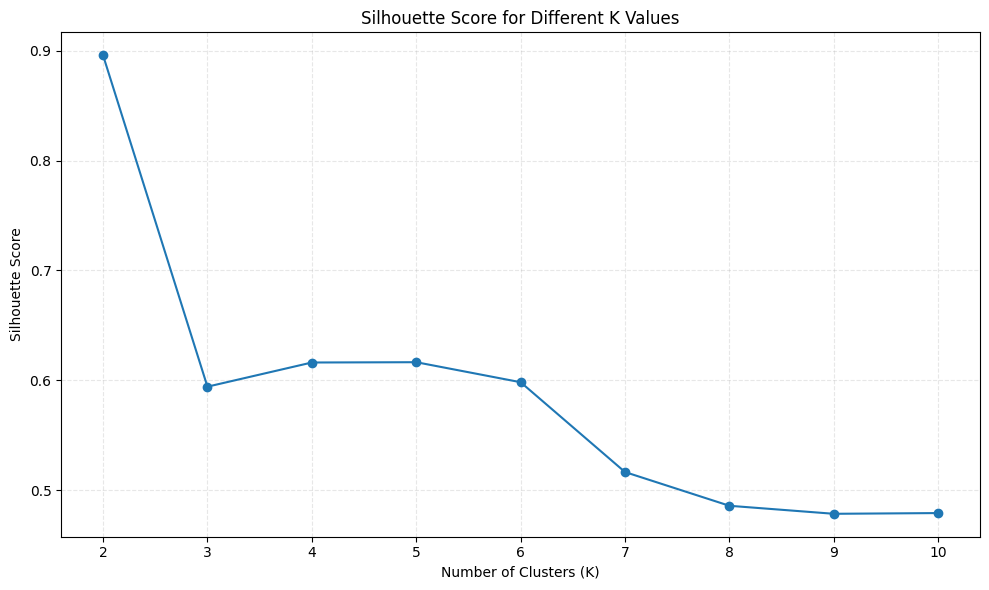

In [12]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.896
K = 3: Silhouette Score = 0.594
K = 4: Silhouette Score = 0.616
K = 5: Silhouette Score = 0.616
K = 6: Silhouette Score = 0.598
K = 7: Silhouette Score = 0.517
K = 8: Silhouette Score = 0.486
K = 9: Silhouette Score = 0.479
K = 10: Silhouette Score = 0.479


In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(rfm_scaled)

df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,325,1,77183.60,1,1,5,115,Need Attention,0
1,1,7,4310.00,5,4,5,545,Champions,1
2,74,4,1797.24,2,3,4,234,At Risk,1
3,18,1,1757.55,4,1,4,414,Potential Loyalists,1
4,309,1,334.40,1,1,2,112,Lost Customers,0


In [15]:
cluster_summary = df.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,246.106285,1.582255,629.663689
1,40.454180,4.673065,1849.670202
2,5.038462,66.423077,85826.078077


In [16]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

In [17]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_percentage = (
    cluster_counts / len(df) * 100
).round(2)

cluster_overview = pd.DataFrame({
    'Customer Count': cluster_counts,
    'Percentage': cluster_percentage
})

cluster_overview

,Customer Count,Percentage
Cluster,,
0,1082,24.94
1,3230,74.46
2,26,0.60


In [18]:
cluster_names = {
    0: 'Inactive / Low-Value',
    1: 'Regular / Valuable',
    2: 'VIP / High-Value'
}

df['Customer_Segment'] = df['Cluster'].map(cluster_names)

df[['Cluster', 'Customer_Segment']].head()

,Cluster,Customer_Segment
0,0,Inactive / Low-Value
1,1,Regular / Valuable
2,1,Regular / Valuable
3,1,Regular / Valuable
4,0,Inactive / Low-Value


In [19]:
df[['Cluster', 'Customer_Segment']].drop_duplicates().sort_values('Cluster')

,Cluster,Customer_Segment
0,0,Inactive / Low-Value
1,1,Regular / Valuable
55,2,VIP / High-Value


In [20]:
df.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)